# **Проектирование экспериментов в *comet***

Визуализируйте корреляцию между 7 числовыми признаками, использованными для обучения модели, и залогируйте изображение в *Comet*.

In [162]:
# Импорт библиотек

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from comet_ml import Experiment

In [163]:
# Создайте эксперимент с помощью вашего API ключа
experiment = Experiment(
    api_key="sVMPd1D6HeyPMMo4guE6hw6Ig",
    project_name="medical-appointment",
    workspace="kjottboller",
)

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Experiment is live on comet.com https://www.comet.com/kjottboller/medical-appointment/281b55b22d174f25872df6e56174c78a



In [164]:
data = pd.read_csv('D:/Skillfactory/data/Kaggle_Medical.csv')

In [165]:
data.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


In [166]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [167]:
numeric_cols = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap','SMS_received']

## **Неинформативные значения**

In [168]:
data_dupl = list(data.columns)
mask = data.duplicated(subset = data_dupl)
data_duplicates = data[mask]
print(f'Число найденных дубликатов: {data_duplicates.shape[0]}') 

Число найденных дубликатов: 0


In [169]:
print("Уникальные значения в `Age` => {}".format(data.Age.unique()))

Уникальные значения в `Age` => [ 62  56   8  76  23  39  21  19  30  29  22  28  54  15  50  40  46   4
  13  65  45  51  32  12  61  38  79  18  63  64  85  59  55  71  49  78
  31  58  27   6   2  11   7   0   3   1  69  68  60  67  36  10  35  20
  26  34  33  16  42   5  47  17  41  44  37  24  66  77  81  70  53  75
  73  52  74  43  89  57  14   9  48  83  72  25  80  87  88  84  82  90
  94  86  91  98  92  96  93  95  97 102 115 100  99  -1]


In [170]:
# Удаление аномальных значений

data = data[(data.Age >=0) & (data.Age <= 102)]
data.Age.value_counts()

Age
0      3539
1      2273
52     1746
49     1652
53     1651
       ... 
97       11
98        6
100       4
102       2
99        1
Name: count, Length: 102, dtype: int64

- Для анализа корреляция выберите 7 числовых признаков и зафиксируйте их в переменной numeric_data.  
- Для визуализации корреляций воспользуйтесь тепловой матрицей.  
- Логирование графиков в Comet происходит с помощью метода log_figure().  

### **Кодировка категориальных признаков**

In [171]:
categorical_columns_names = ['Gender', 'Neighbourhood']
encoded_columns = pd.get_dummies(data, columns = categorical_columns_names)
encoded_columns.drop(['AppointmentID', 'PatientId', 'ScheduledDay', 'AppointmentDay', 'No-show'], axis=1, inplace = True)
encoded_columns.head()

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,Gender_F,Gender_M,Neighbourhood_AEROPORTO,...,Neighbourhood_SANTOS REIS,Neighbourhood_SEGURANÇA DO LAR,Neighbourhood_SOLON BORGES,Neighbourhood_SÃO BENEDITO,Neighbourhood_SÃO CRISTÓVÃO,Neighbourhood_SÃO JOSÉ,Neighbourhood_SÃO PEDRO,Neighbourhood_TABUAZEIRO,Neighbourhood_UNIVERSITÁRIO,Neighbourhood_VILA RUBIM
0,62,0,1,0,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,56,0,0,0,0,0,0,False,True,False,...,False,False,False,False,False,False,False,False,False,False
2,62,0,0,0,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,8,0,0,0,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,56,0,1,1,0,0,0,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [172]:
y = data['No-show']
y

0         No
1         No
2         No
3         No
4         No
          ..
110522    No
110523    No
110524    No
110525    No
110526    No
Name: No-show, Length: 110521, dtype: object

In [173]:
y = y.replace({'No': 0, 'Yes': 1})
y.value_counts(True)

C:\Users\akres\AppData\Local\Temp\ipykernel_10340\1743858308.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'No': 0, 'Yes': 1})


No-show
0    0.798084
1    0.201916
Name: proportion, dtype: float64

### **Корреляция**

In [174]:
numeric_cols = ['Age', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received']
numeric_data = data[numeric_cols]

In [175]:
correlation = numeric_data.corr() # Расчёт корреляции
correlation

,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
Age,1.000000,-0.092437,0.504726,0.292509,0.095862,0.077369,0.012676
Scholarship,-0.092437,1.000000,-0.019731,-0.024899,0.035019,-0.008520,0.001188
Hipertension,0.504726,-0.019731,1.000000,0.433096,0.087972,0.080249,-0.006309
Diabetes,0.292509,-0.024899,0.433096,1.000000,0.018471,0.057629,-0.014555
Alcoholism,0.095862,0.035019,0.087972,0.018471,1.000000,0.004689,-0.026151
Handcap,0.077369,-0.008520,0.080249,0.057629,0.004689,1.000000,-0.024026
SMS_received,0.012676,0.001188,-0.006309,-0.014555,-0.026151,-0.024026,1.000000


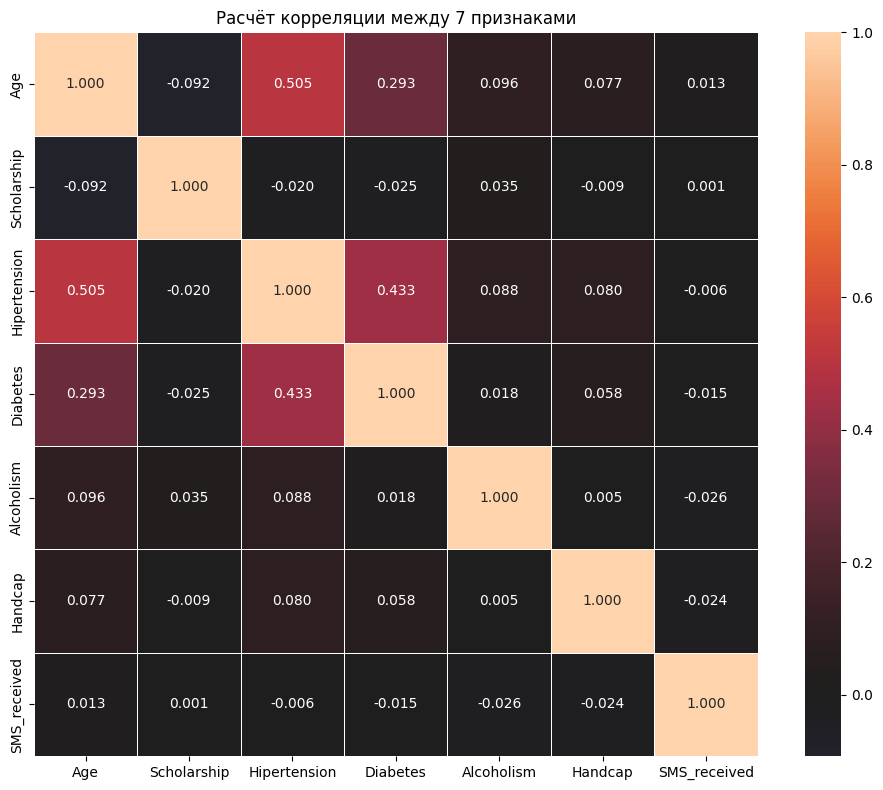

In [176]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, center = 0,
            square=True, fmt='.3f', linewidths=0.5)
plt.title('Расчёт корреляции между 7 признаками')
plt.tight_layout()

experiment.log_figure(
    figure_name='Correlation Heatmap', 
    figure=plt.gcf()
)

plt.show()

### **Шкалирование данных**

In [177]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(encoded_columns)

print(X.shape)

(110521, 90)


### **Инициализация модели**

In [178]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [179]:
logreg = LogisticRegression()
random_state = 42

### **Обучение модели**

In [180]:
logreg.fit(X, y)

LogisticRegression()

### **Логирование параметров обучения**

In [181]:
params = {'random_state':random_state,
          'model_type':'logreg'}
experiment.log_parameters(params)

### **Предсказание модели**

In [182]:
y_pred = logreg.predict(X)

### **Анализ модели**

In [183]:
accuracy = accuracy_score(y, y_pred)
print('Доля правильных ответов: {:6.3f}'.format(accuracy))

Доля правильных ответов:  0.798


### **Логирование метрик**

In [184]:
metrics = {'accuracy':accuracy}
experiment.log_metrics(metrics)

In [185]:
experiment.log_confusion_matrix(y.tolist(), y_pred.tolist())
experiment

In [186]:
experiment.end()

COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO: Comet.ml Experiment Summary
COMET INFO: ---------------------------------------------------------------------------------------
COMET INFO:   Data:
COMET INFO:     display_summary_level : 1
COMET INFO:     name                  : colourful_tread_7414
COMET INFO:     url                   : https://www.comet.com/kjottboller/medical-appointment/281b55b22d174f25872df6e56174c78a
COMET INFO:   Metrics:
COMET INFO:     accuracy : 0.7980836221170637
COMET INFO:   Parameters:
COMET INFO:     C                 : 1.0
COMET INFO:     class_weight      : None
COMET INFO:     clip              : False
COMET INFO:     copy              : True
COMET INFO:     dual              : False
COMET INFO:     feature_range     : (0, 1)
COMET INFO:     fit_intercept     : True
COMET INFO:     intercept_scaling : 1
COMET INFO:     l1_ratio          : None
COMET INFO:     max_iter          : 100
COMET 